<a href="https://colab.research.google.com/github/IrineuBovoJunior398/Pos-em-IA/blob/main/MEUDATASET_PERCEPTRON_SIMPLES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Acurácia do Perceptron: 50.00%

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.67      0.57      0.62         7
           1       0.25      0.33      0.29         3

    accuracy                           0.50        10
   macro avg       0.46      0.45      0.45        10
weighted avg       0.54      0.50      0.52        10



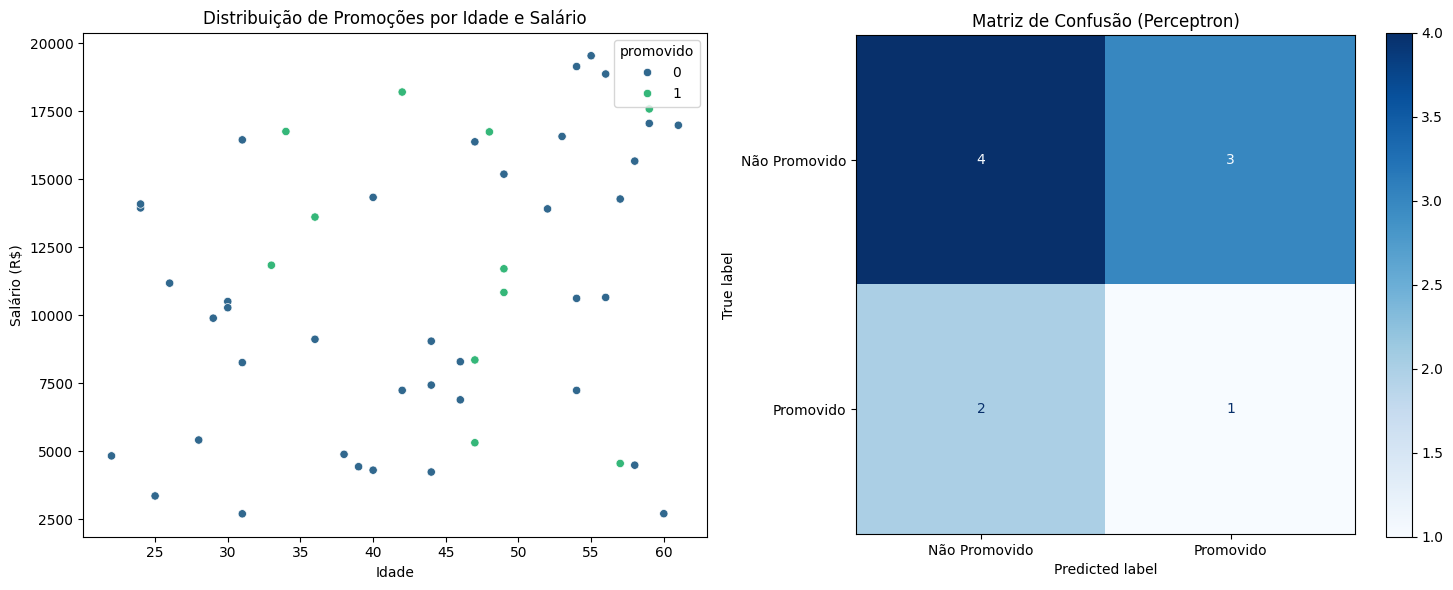

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Criação do DataFrame (como você pediu antes) ---
np.random.seed(42)
n = 50

# Campos base
nomes = [f"Pessoa_{i:02d}" for i in range(1, n + 1)]

start = datetime(1965, 1, 1)
end = datetime(2005, 12, 31)
dias = (end - start).days

datas_nascimento = [start + timedelta(days=int(np.random.randint(0, dias))) for _ in range(n)]
datas_nascimento = pd.to_datetime(datas_nascimento)

hoje = pd.Timestamp.today().normalize()
idade = (hoje.year - datas_nascimento.year).astype(int)

cpf = [str(np.random.randint(10**10, 10**11 - 1)).zfill(11) for _ in range(n)]

cargos = np.random.choice(
    ["Analista Jr", "Analista Pleno", "Analista Sr", "Cientista de Dados", "Eng. de Dados", "Gestor"],
    size=n,
    p=[0.25, 0.25, 0.20, 0.15, 0.10, 0.05]
)

salario = np.random.randint(2500, 20001, size=n)

df = pd.DataFrame({
    "Nome": nomes,
    "data_nascimento": datas_nascimento.date,
    "idade": idade,
    "CPF": cpf,
    "cargo": cargos,
    "salario": salario
})

# Classificação conforme salário
def classificar_salario(s):
    if s <= 5000:
        return "C"
    elif 5001 <= s <= 10000:
        return "B"
    elif 10000 < s <= 20000:
        return "A"
    else:
        return np.nan

df["classificacao"] = df["salario"].apply(classificar_salario)

# Alvo 1 (CLASSIFICAÇÃO): promovido (0/1)
prob_promocao_base = np.where(df["classificacao"] == "C", 0.05,
                      np.where(df["classificacao"] == "B", 0.15, 0.30))

bonus_cargo = df["cargo"].map({
    "Analista Jr": 0.00,
    "Analista Pleno": 0.03,
    "Analista Sr": 0.06,
    "Cientista de Dados": 0.07,
    "Eng. de Dados": 0.07,
    "Gestor": 0.10
}).fillna(0.0)

bonus_idade = np.clip((df["idade"] - 25) / 100, 0, 0.10)

prob_promovido = np.clip(prob_promocao_base + bonus_cargo + bonus_idade, 0, 0.85)
df["promovido"] = (np.random.rand(n) < prob_promovido).astype(int)

# Alvo 2 (REGRESSÃO): bonus_anual (R$)
percentual_bonus = np.where(df["classificacao"] == "C", 0.04,
                     np.where(df["classificacao"] == "B", 0.07, 0.10))

bonus_por_cargo = df["cargo"].map({
    "Analista Jr": 500,
    "Analista Pleno": 1200,
    "Analista Sr": 2200,
    "Cientista de Dados": 2500,
    "Eng. de Dados": 2500,
    "Gestor": 4000
}).fillna(800)

ruido = np.random.normal(loc=0, scale=800, size=n)

df["bonus_anual"] = (
    df["salario"] * percentual_bonus
    + bonus_por_cargo
    + df["promovido"] * 1500
    + ruido
).round(2)

df["bonus_anual"] = df["bonus_anual"].clip(lower=0)

# --- Agora o código de ML que você quer executar ---

# 1. Preparação dos Dados (Features e Target)
df_ml = pd.get_dummies(df, columns=['cargo', 'classificacao'], drop_first=True)

X = df_ml.drop(columns=['Nome', 'data_nascimento', 'CPF', 'promovido', 'bonus_anual'])
y = df_ml['promovido']

# 2. Divisão em Treino e Teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Normalização (Essencial para o Perceptron)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Treinamento da Rede Perceptron
modelo_perceptron = Perceptron(max_iter=1000, tol=1e-3, random_state=42)
modelo_perceptron.fit(X_train_scaled, y_train)

# 5. Predição e Avaliação
y_pred = modelo_perceptron.predict(X_test_scaled)
acuracia = accuracy_score(y_test, y_pred)

print(f"Acurácia do Perceptron: {acuracia:.2%}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

# 6. Visualização de Dados Relevantes
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Dispersão de Salário vs Idade colorido por Promoção
sns.scatterplot(data=df, x='idade', y='salario', hue='promovido', palette='viridis', ax=ax[0])
ax[0].set_title('Distribuição de Promoções por Idade e Salário')
ax[0].set_xlabel('Idade')
ax[0].set_ylabel('Salário (R$)')

# Gráfico 2: Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Promovido', 'Promovido'])
disp.plot(cmap='Blues', ax=ax[1], values_format='d')
ax[1].set_title('Matriz de Confusão (Perceptron)')

plt.tight_layout()
plt.show()